In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [4]:
import bayesflow as bf

INFO:bayesflow:Using backend 'jax'


In [5]:
from src.simulations.molecules import MoleculeSimulator
from src.simulations.benchmarks.ethene import ethene, ethene_configs
from pathlib import Path

In [6]:
checkpoint_path = Path("checkpoints")
checkpoint_path.mkdir(parents=True, exist_ok=True)

## Simulator + Dataset

In [7]:
ethene_simulator = MoleculeSimulator(
    molecule_fun=ethene,
    basis="cc-pVDZ",
    coord_scale=1.,
    cache_integrals=False
)

In [8]:
# Prior function to sample geometric configuration for ethene
ethene_configs = ethene_configs

In [9]:
test = ethene_simulator.sample(
    batch_size=1,
    molecule_config=ethene_configs,
    molecule_kwargs={ "perturb": False },
    include_kwargs={
        "include_hartree_fock": True,
        "include_configs": True,
    }
)

Generating samples: 100%|██████████| 1/1 [00:00<00:00,  1.21it/s]


In [10]:
for k, v in test.items():
    print(k, v.shape)

occupancies (1, 48)
determinant (1, 2304)
hf_energy (1, 1)
cc_bond_distance (1, 1)
ch_bond_distance (1, 1)
hch_angle (1, 1)
twist_angle (1, 1)


In [11]:
training_set = ethene_simulator.sample(
    batch_size=10000,
    molecule_config=ethene_configs,
    molecule_kwargs={ "perturb": False },
    include_kwargs={
        "include_hartree_fock": True,
        "include_configs": True,
    }
)

Generating samples: 100%|██████████| 10000/10000 [2:09:18<00:00,  1.29it/s] 


In [12]:
validation_set = ethene_simulator.sample(
    batch_size=500,
    molecule_config=ethene_configs,
    molecule_kwargs={ "perturb": False },
    include_kwargs={
        "include_hartree_fock": True,
        "include_configs": True,
    }
)

Generating samples: 100%|██████████| 500/500 [06:35<00:00,  1.26it/s]


In [13]:
for k, v in validation_set.items():
    print(k, v.shape)

occupancies (500, 48)
determinant (500, 2304)
hf_energy (500, 1)
cc_bond_distance (500, 1)
ch_bond_distance (500, 1)
hch_angle (500, 1)
twist_angle (500, 1)


## Adapter

In [77]:
inference_variables = ["cc_bond_distance", "ch_bond_distance", "hch_angle", "twist_angle"]
inference_conditions = ["determinant", "hf_energy", "occupations"]

adapter = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .scale(["hch_angle", "twist_angle"], by=1./180)
    .concatenate(inference_conditions, axis=-1, into="inference_conditions")
    .concatenate(inference_variables, into="inference_variables")
)

### Flow Matching

In [78]:
flow_matching = bf.networks.FlowMatching()

In [79]:
flow_matching_workflow = bf.workflows.BasicWorkflow(
    simulator=ethene_simulator,
    adapter=adapter,
    inference_network=flow_matching,
    checkpoint_filepath=checkpoint_path / "ethene_flow_matching.ckpt"
)

Existing checkpoints can _not_ be restored/loaded using this workflow. Upon refitting, the checkpoints will be overwritten. To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model(...)


In [94]:
%%time
flow_matching_history = flow_matching_workflow.fit_offline(
    data=training_set,
    val_data=validation_set,
    epochs=100,
    batch_size=32
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.


Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - loss: 0.3328
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step - loss: 0.3254
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 869us/step - loss: 0.3193
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - loss: 0.3345
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - loss: 0.3288
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step - loss: 0.3216
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step - loss: 0.3279
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step - loss: 0.3352
Epoch 9/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step - loss: 0.3341
Epoch 10/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - loss: 0.3282
Epoch 11/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step - loss: 0.3292
Epoch 12/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step - loss: 0.3286
Epoch 13/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step - loss: 0.3286
Epoch 14/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 929us/step - loss: 0.3275
Epoch 15/100
31

INFO:bayesflow:Training is now finished.
            You can find the trained approximator at 'checkpoints/ethene_flow_matching.ckpt/model.model.keras'.
            To load it, use approximator = keras.saving.load_model(...).


CPU times: user 25 s, sys: 5.72 s, total: 30.8 s
Wall time: 24.3 s


In [92]:
fig_size = (16, 4)
variable_names = [r"$D_{\text{C-C}}$", r"$D_{\text{C-H}}$", r"$\theta$", r"$\phi$"]

CPU times: user 2 μs, sys: 2 μs, total: 4 μs
Wall time: 7.87 μs


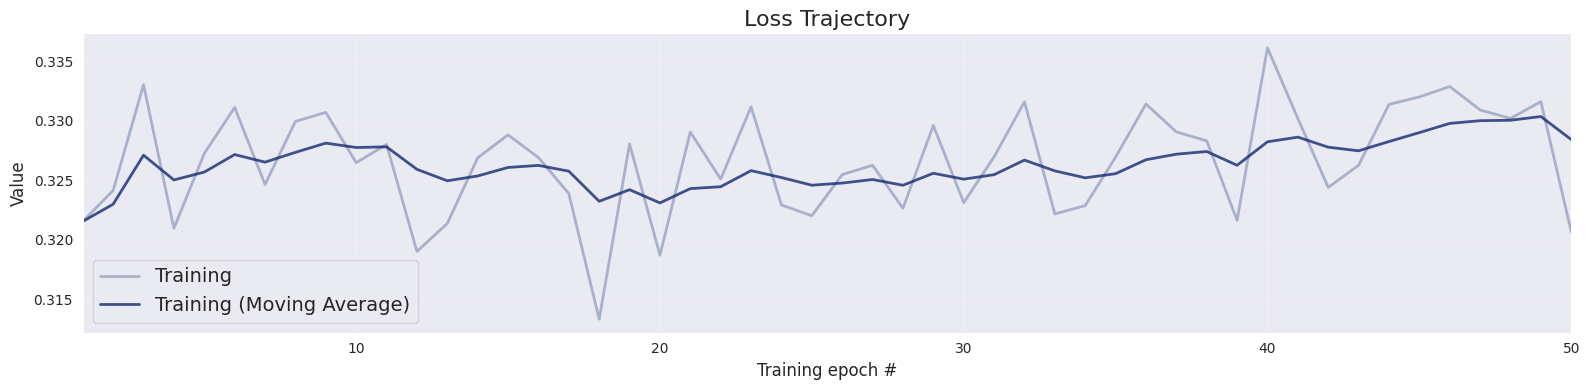

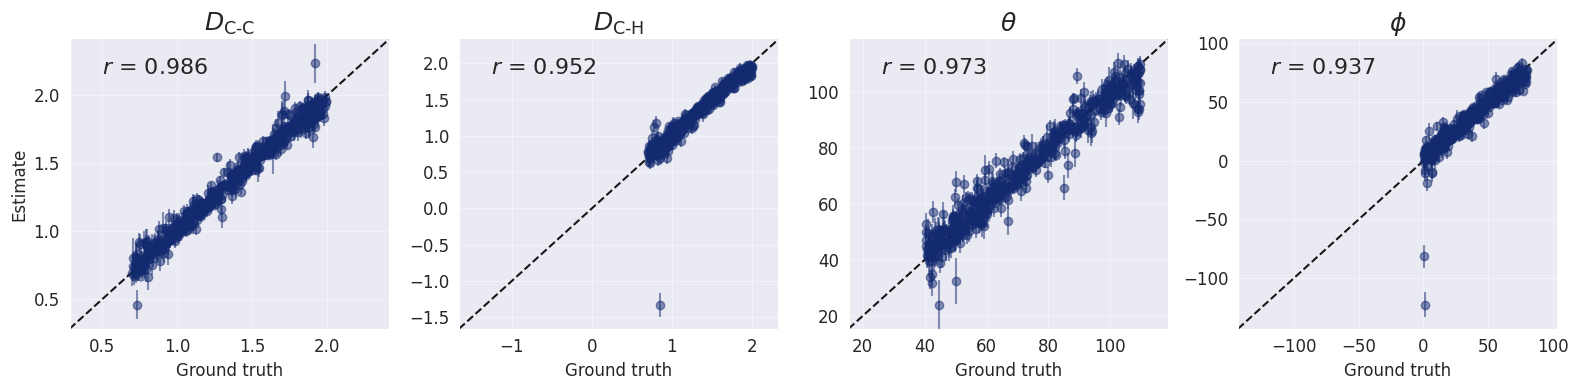

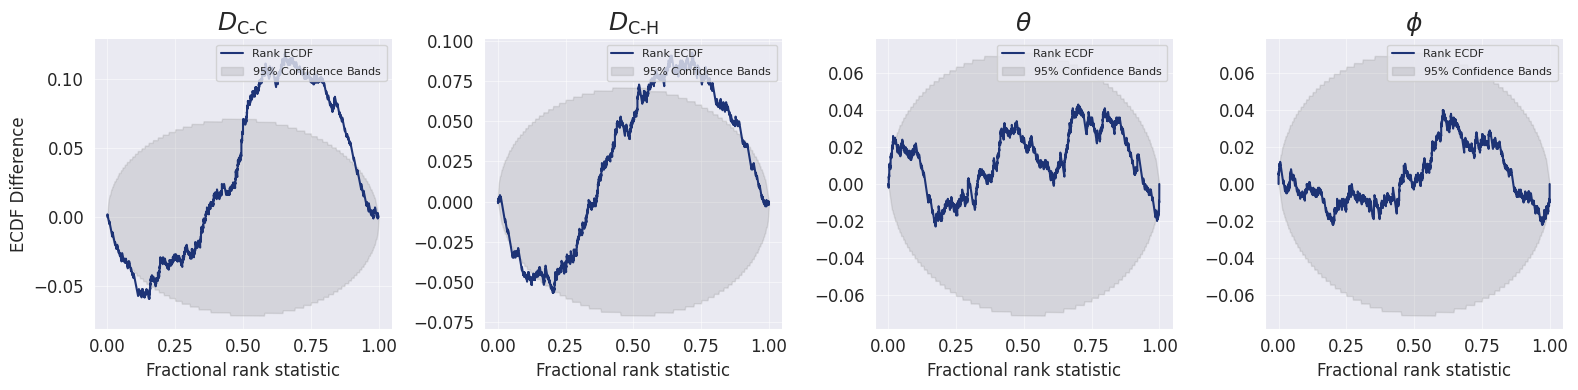

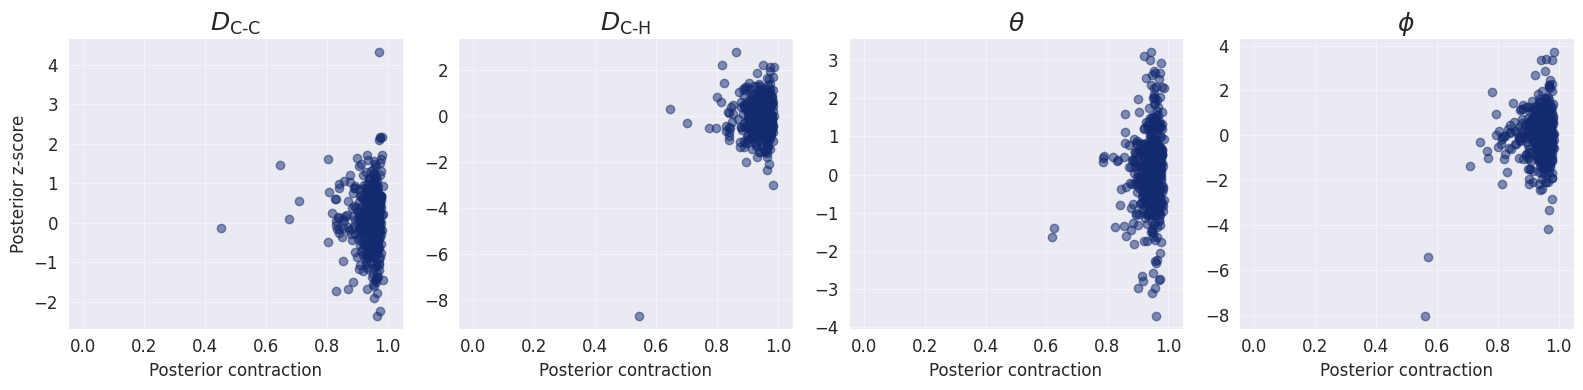

In [93]:
%time
figures = flow_matching_workflow.plot_default_diagnostics(
    test_data=validation_set,
    variable_names=variable_names,
    loss_kwargs={"figsize": fig_size, "label_fontsize": 12},
    recovery_kwargs={"figsize": fig_size, "label_fontsize": 12},
    calibration_ecdf_kwargs={"figsize": fig_size, "legend_fontsize": 8, "difference": True,
                             "label_fontsize": 12},
    z_score_contraction_kwargs={"figsize": fig_size, "label_fontsize": 12}
)

In [59]:
metrics = flow_matching_workflow.compute_default_diagnostics(test_data=validation_set)
metrics

,cc_bond_distance,ch_bond_distance,hch_angle,twist_angle
NRMSE,0.059028,0.063602,0.073495,0.096010
Posterior Contraction,0.983837,0.984338,0.983979,0.983945
Calibration Error,0.012895,0.021737,0.089895,0.044053


In [60]:
## Posterior Predictive Check

In [88]:
validation_set.keys()

dict_keys(['occupancies', 'determinant', 'hf_energy', 'cc_bond_distance', 'ch_bond_distance', 'hch_angle', 'twist_angle'])

In [89]:
validation_set["occupancies"][0]

array([2., 2., 2., 2., 2., 2., 2., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])